## 경사하강법 실습

- MSE(Mean Square Error) 함수를 만들고, 해당 지표의 값을 최소로 만들어주는 선형 회귀 함수를 찾는다.

Text(0.5, 1.0, 'y = 4 + 3x + noise')

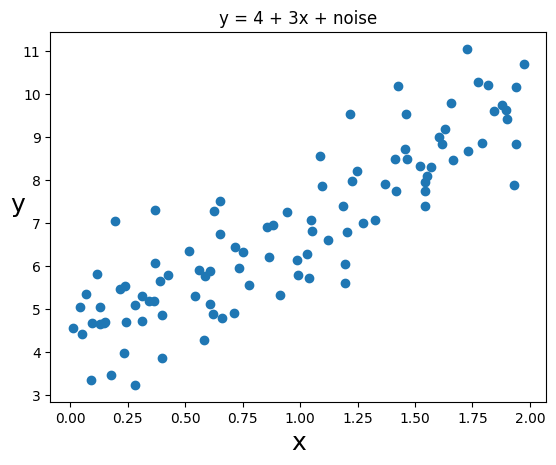

In [2]:
## 데이터 생성 및 시각화

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# y = 4 + 3x 관계의 데이터 생성 (노이즈 포함)
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

plt.scatter(X, y)
plt.xlabel("x", fontsize=18)
plt.ylabel("y", rotation=0, fontsize=18)
plt.title("y = 4 + 3x + noise")

In [3]:
## 랜덤한 값을 가진 선형 회귀 함수 생성

W = np.random.randn(1)
b = np.random.randn(1)
print(W, b)

[0.01300189] [1.45353408]


Text(0, 0.5, 'y')

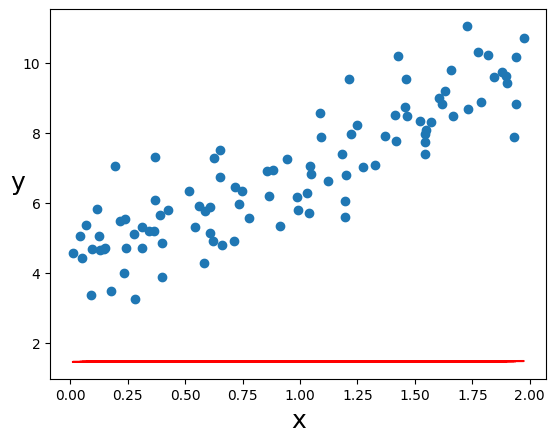

In [4]:
## 데이터셋, 회귀 함수 시각화

y_pred = W * X + b
plt.plot(X,y_pred,'r')
plt.scatter(X,y)
plt.xlabel("x", fontsize=18)
plt.ylabel("y", rotation=0, fontsize=18)

In [5]:
## 평가 지표(MSE) 함수 생성

def MSE(y, y_pred):
    m = len(y)
    cost = (1/m) * np.sum(np.square(y_pred-y))
    
    return cost
    
print(MSE(y, y_pred))

32.138586076383035


#### 손실함수 기울기 조정 공식

<img src="https://velog.velcdn.com/images/newnew_daddy/post/08c681cc-3698-4236-9cec-84d7bc9452e8/image.png" width=80%>

```python
w_gradient = (2/len(X)) * np.dot(X.T, (y_pred - y)).sum()
b_gradient = (2/len(X)) * np.sum(y_pred - y)
```

In [6]:
"""
손실 함수의 기울기를 조정해주는 함수를 통해 W, b 값을 지속적으로 업데이트.
최종적으로는 MSE가 일정 값 이하로 떨어질때까지 반복
"""
y_preds = []
epsilon = 0.03
learning_rate = 0.01

for epoch in range(1000):
    # 예측값 계산
    y_pred = W * X + b
    y_preds.append(y_pred)
    # MSE 계산
    mse = np.mean((y_pred - y)**2)
    
    if mse < epsilon:
        print("Reached MSE below 0.03")
        break
    
    # w와 b 업데이트
    w_gradient = (2/len(X)) * np.dot(X.T, (y_pred - y)).sum()
    b_gradient = (2/len(X)) * np.sum(y_pred - y)
    W -= learning_rate * w_gradient
    b -= learning_rate * b_gradient

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}, MSE: {mse:.4f}')

print(f'Final Parameters: w={W[0]:.4f}, b={b[0]:.4f}')

Epoch: 0, MSE: 32.1386
Epoch: 100, MSE: 0.8186
Epoch: 200, MSE: 0.8092
Epoch: 300, MSE: 0.8079
Epoch: 400, MSE: 0.8073
Epoch: 500, MSE: 0.8069
Epoch: 600, MSE: 0.8068
Epoch: 700, MSE: 0.8067
Epoch: 800, MSE: 0.8066
Epoch: 900, MSE: 0.8066
Final Parameters: w=2.7755, b=4.2090


/Users/hyunsoo.lee/Desktop/Personal_Studies/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hyunsoo.lee/Desktop/Personal_Studies/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hyunsoo.lee/Desktop/Personal_Studies/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hyunsoo.lee/Desktop/Personal_Studies/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hyunsoo.lee/Desktop/Personal_Studies/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 48277 (\

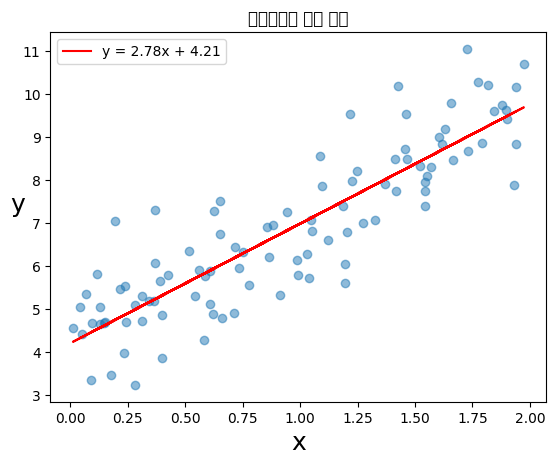

In [7]:
## 학습 완료 후 회귀선 시각화

y_pred = W * X + b
plt.plot(X, y_pred, 'r-', label=f'y = {W[0]:.2f}x + {b[0]:.2f}')
plt.scatter(X, y, alpha=0.5)
plt.xlabel("x", fontsize=18)
plt.ylabel("y", rotation=0, fontsize=18)
plt.title("경사하강법 학습 결과")
plt.legend()

## 학습률(Learning Rate) 알파
- 각 반복(iteration)마다 매개변수(또는 가중치)를 업데이트할 때 사용하는 스텝 크기

1) **학습률이 너무 작은 경우**:
    - 학습이 매우 느리게 진행되어 많은 반복이 필요합니다.
    - 시간이 많이 걸리며, 최적의 매개변수에 수렴하는 데 오랜 시간이 걸릴 수 있습니다.
    - 국소 최적값(local optimum)에 갇힐 가능성이 있습니다.
    <img src="https://velog.velcdn.com/images/newnew_daddy/post/81953bda-b296-4ce2-929b-adc1f76dbdc6/image.png" width=80%>
2) **학습률이 너무 큰 경우**:
    - 매개변수가 최적값을 지나쳐서 발산할 수 있습니다.
    - 학습이 불안정하게 진행되며, 손실 함수 값이 발산하거나 진동할 수 있습니다.
    - 최적의 매개변수에 도달하지 못할 가능성이 높습니다.
    <img src="https://velog.velcdn.com/images/newnew_daddy/post/0677760d-5781-4de8-8b47-077386e8d2b3/image.png" width=80%>
3) **변곡점 여러개 있는 경우**
    - 그림에서 '평지' 혹은 '지역 최소값'을 '전역 최소값'으로 착각하여 손실 함수를 최소화 시키지 못하는 경우가 생길 수 있습니다.
    - 이런 경우 여러개의 초기값으로 경사하강법을 시도, 학습률의 점진적인 조정 등으로 보완
    <img src="https://velog.velcdn.com/images/newnew_daddy/post/25e6f8d8-d6a2-401a-9b8c-9a0c89e6044d/image.png" width=80%>
    
### **적절한 알파값을 선택하는 것이 중요!**
- 일반적으로 1.0 ~ 0.0 사이의 숫자로 정하고(1,0.1, 0.01, 0.001 또는 0.5, 0.05, 0.005 이런 식으로), 여러 개를 실험해보면서 경사 하강을 제일 적게 하면서 손실이 잘 줄어드는 학습률을 선택합니다.

In [8]:
y_preds = gradient_descent(100, 1.1, 0.01)

plt.figure()
plt.scatter(X, y)
for index, y_pred in enumerate(y_preds):
    plt.plot(X, y_pred, 'r-', linewidth=0.01)
plt.xlabel("x", fontsize=18)
plt.ylabel("y", rotation=0, fontsize=18)
plt.show()

NameError: name 'gradient_descent' is not defined

## 경사하강법 알고리즘의 종류

#### 1. 배치 경사 하강법 (Batch Gradient Descent, BGD)
- **특성**
  - 매 반복마다 전체 데이터셋을 사용하여 비용 함수의 기울기를 계산
  - 전체 데이터셋을 사용하기 때문에, 매번 업데이트가 안정적이며 일관되게 최소값으로 수렴
- **단점**
  - 전체 데이터셋을 메모리에 적재해야 하므로, 데이터셋이 매우 큰 경우 비실용적이며 계산에 시간이 많이 걸림
- **사용** : 데이터셋이 작거나 중간 크기일 때

#### 2. 확률적 경사 하강법 (Stochastic Gradient Descent, SGD)
- **특성**
  - 매 반복마다 하나의 샘플만을 사용하여 기울기를 계산(배치 크기가 1)
  - 샘플 하나만 사용하므로, 계산이 빠르며 실시간 업데이트가 가능. 효율적인 메모리 사용
  - 데이터셋의 크기가 크더라도 적용이 가능하다.
- **단점**
  - 매번 다른 샘플을 사용하므로, 업데이트의 변동성이 커서 최적화 과정이 불안정할 수 있음.
- **사용** : 데이터셋이 매우 크거나 실시간으로 데이터가 들어오는 경우
#### 3. 미니 배치 경사 하강법 (Mini-Batch Gradient Descent)
- **특성**
  - 배치 경사 하강법(BGD)이나 확률적 경사 하강법(SGD)을 혼용한 방법
  - 매 반복마다 데이터셋의 작은 부분 집합(미니 배치)을 사용하여 기울기를 계산
  - 배치 크기를 지정할 수 있기 때문에 성능 및 메모리 최적화가 용이하다.
- **사용** : 중간 크기의 데이터셋이나 계산 효율성을 높이고 싶은 경우
---
<img src="https://velog.velcdn.com/images/newnew_daddy/post/8ba96866-cb7f-4144-9c23-4d6354cd36aa/image.png" width=80%>

#### !!BGD, MBGD의 경우 따로 메소드가 구현되어 있지 않고, SGD만 sklearn에서 사용할 수 있다.

## 경사하강법을 이용한 회귀 - SGDRegressor

#### Stochastic Gradient Descent (확률론적 경사 하강법)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.metrics import mean_squared_error

In [10]:
gold_data = pd.read_csv('dataset/gld_price_data.csv')

gold_data.head(), gold_data.shape

(       Date          SPX        GLD        USO     SLV   EUR/USD
 0  1/2/2008  1447.160034  84.860001  78.470001  15.180  1.471692
 1  1/3/2008  1447.160034  85.570000  78.370003  15.285  1.474491
 2  1/4/2008  1411.630005  85.129997  77.309998  15.167  1.475492
 3  1/7/2008  1416.180054  84.769997  75.500000  15.053  1.468299
 4  1/8/2008  1390.189941  86.779999  76.059998  15.590  1.557099,
 (2290, 6))

In [11]:
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [12]:
X = gold_data.drop(['Date','GLD'],axis=1)
y = gold_data['GLD']

In [13]:
from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
df_std = scaler_standard.fit_transform(X)

df_std = pd.DataFrame(df_std, columns=X.columns)

df_std

,SPX,USO,SLV,EUR/USD
0,-0.399145,2.388810,-0.691720,1.429753
1,-0.399145,2.383687,-0.676912,1.451035
2,-0.467604,2.329381,-0.693553,1.458646
3,-0.458837,2.236652,-0.709630,1.403954
4,-0.508915,2.265342,-0.633900,2.079145
...,...,...,...,...
2285,1.960708,-0.911009,-0.645182,-0.736505
2286,2.010555,-0.895128,-0.642361,-0.752222
2287,2.059264,-0.893078,-0.612747,-0.698761
2288,2.072867,-0.894615,-0.638131,-0.688383


In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state=2)

In [15]:
lr = LinearRegression()

lr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# 예측 및 성능 평가
y_test_pred = lr.predict(X_test)

mean_squared_error(Y_test, y_test_pred)

70.78890079721529

In [17]:
lr.score(X_train, Y_train), lr.score(X_test, Y_test)

(0.8850695972446934, 0.8657886565869237)

In [18]:
sgd_reg = SGDRegressor(
    max_iter=1000,      # 최대 반복 횟수. 경사하강법의 최대 반복 횟수를 설정. 지정된 반복 횟수까지 수렴하지 않으면 학습을 중단.
    tol=0.001,          # 수렴 허용 오차. 비용 함수의 변화가 이 값보다 작아지면 학습을 멈춤.
    penalty=None,       # 규제(정규화) 유형. 'l2', 'l1', 'elasticnet' 등의 값을 가질 수 있으며, None은 규제를 사용하지 않음을 의미.
    eta0=0.1,           # 초기 학습률.
    random_state=42     # 랜덤 시드.
)

In [19]:
sgd_reg.fit(X_train, Y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [20]:
# 예측 및 성능 평가
y_test_pred = sgd_reg.predict(X_test)

mean_squared_error(Y_test, y_test_pred)


5.774167090785741e+30

In [21]:
sgd_reg.score(X_train, Y_train), sgd_reg.score(X_test, Y_test)

(-1.0317873841061005e+28, -1.094746088183946e+28)

In [23]:
# 스케일링된 데이터로 SGDRegressor 재학습
X_train_std, X_test_std, Y_train_std, Y_test_std = train_test_split(
    df_std, y, test_size=0.2, random_state=2
)

sgd_reg_scaled = SGDRegressor(
    max_iter=1000,
    tol=0.001,
    penalty=None,
    eta0=0.01,
    random_state=42
)
sgd_reg_scaled.fit(X_train_std, Y_train_std)

# 스케일링 후 성능 확인
y_test_pred_scaled = sgd_reg_scaled.predict(X_test_std)
print(f"스케일링 후 MSE : {mean_squared_error(Y_test_std, y_test_pred_scaled):.4f}")
print(f"Train Score: {sgd_reg_scaled.score(X_train_std, Y_train_std):.4f}")
print(f"Test  Score: {sgd_reg_scaled.score(X_test_std, Y_test_std):.4f}")

스케일링 후 MSE : 70.9223
Train Score: 0.8851
Test  Score: 0.8655
